# FX Data Generation
**Part 1 of 2 — StoneX Senior BA Portfolio Demo**  
Date: 2026-06-14  
Data Source: [Philippe Remy / FX 1-Minute Data](https://github.com/philipperemy/FX-1-Minute-Data)  

This notebook **generates** simulated client trading data from raw FX prices and exports two CSV files:
- `clients.csv` — 500 simulated retail clients with tier, region, balance, leverage
- `transactions.csv` — ~12,000 simulated trades with P&L, spread revenue, margin metrics

Run the **Analysis notebook** (`FX_analysis.ipynb`) after this one to visualize and analyze the data.

## Required Packages

Run this once before starting:
```bash
pip install pandas numpy matplotlib seaborn scipy statsmodels
```

In [1]:
# ============================================================
# Section 0: Imports & Global Settings
# ============================================================
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print('pandas version :', pd.__version__)
print('numpy  version :', np.__version__)

# Color scheme by client tier (also saved for analysis notebook)
TIER_COLORS = {
    'Tier 1 VIP':     '#1f77b4',   # blue
    'Tier 2 Regular': '#ff7f0e',   # orange
    'Tier 3 Beginner': '#2ca02c',   # green
}

Libraries loaded successfully.
pandas version : 2.3.3
numpy  version : 1.26.4


## Key FX Concepts Used in This Simulation
Before we load data, here are the FX market conventions that determine our parameter choices.

| Concept | Convention | Used In |
|---------|-------------|--------|
| **Pip size** | 0.0001 for most pairs; 0.01 for JPY pairs | P&L calculation |
| **Pip value** (USD) | `(pip_size x 100,000) / quote_to_USD_rate` | Dynamic per-day |
| **Spread** | Ask - Bid; broker revenue source | Section 2 |
| **Lot size** | 1.0 = 100,000 units (standard); 0.1 = mini; 0.01 = micro | Transaction sim |
| **Leverage** | `Notional Value / Account Balance`; offshore brokers 50-500:1 | Margin calc |
| **Margin Required** | `Notional Value / Leverage` | Margin calc |

> **Data citation:** Raw FX Bid prices from Philippe Remy's public dataset  
> (https://github.com/philipperemy/FX-1-Minute-Data), covering January 2024.

## Section 1: Load Raw FX Data
Load bid prices from Philippe Remy's dataset. Each file is semicolon-separated with columns:
`DateTime; OpenBid; HighBid; LowBid; CloseBid; Volume`

In [4]:
# ============================================================
# Section 1: Load Raw FX Data
# ============================================================
DATA_DIR = 'raw_FX_data/'  # <-- update if your path differs
PAIR_NAMES = [
    'EURUSD', 'GBPUSD', 'USDJPY', 'EURJPY', 'AUDUSD',
    'NZDUSD', 'EURGBP', 'GBPAUD', 'AUDCAD',
]

fx_data = {}
for pair in PAIR_NAMES:
    fname = f'DAT_ASCII_{pair}_M1_2024.csv'
    df = pd.read_csv(DATA_DIR + fname, sep=';', header=0,
                      names=['DateTime','OpenBid','HighBid','LowBid','CloseBid','Volume'])
    df['DateTime'] = pd.to_datetime(df['DateTime'], format='%Y%m%d %H%M%S')
    df = df.set_index('DateTime').sort_index()
    fx_data[pair] = df

print(f'Loaded {len(fx_data)} pairs.')
for pair, df in fx_data.items():
    print(f'  {pair}: {len(df):,} rows  |  {df.index.min()} to {df.index.max()}')

Loaded 9 pairs.
  EURUSD: 372,378 rows  |  2024-01-01 17:01:00 to 2024-12-31 16:58:00
  GBPUSD: 372,106 rows  |  2024-01-01 17:04:00 to 2024-12-31 16:58:00
  USDJPY: 372,082 rows  |  2024-01-01 17:01:00 to 2024-12-31 16:58:00
  EURJPY: 371,530 rows  |  2024-01-01 17:07:00 to 2024-12-31 16:58:00
  AUDUSD: 370,749 rows  |  2024-01-01 17:05:00 to 2024-12-31 16:58:00
  NZDUSD: 370,385 rows  |  2024-01-01 17:05:00 to 2024-12-31 16:58:00
  EURGBP: 370,319 rows  |  2024-01-01 17:05:00 to 2024-12-31 16:58:00
  GBPAUD: 371,581 rows  |  2024-01-01 17:11:00 to 2024-12-31 16:58:00
  AUDCAD: 372,703 rows  |  2024-01-01 17:11:00 to 2024-12-31 16:58:00


In [5]:
# Quick data quality check
for pair, df in fx_data.items():
    nulls = df.isnull().sum().sum()
    print(f'{pair}: {nulls} nulls, {len(df)} rows, '
          f'Close range [{df["CloseBid"].min():.5f}, {df["CloseBid"].max():.5f}]')

EURUSD: 0 nulls, 372378 rows, Close range [1.03398, 1.12122]
GBPUSD: 0 nulls, 372106 rows, Close range [1.22998, 1.34323]
USDJPY: 0 nulls, 372082 rows, Close range [139.58500, 161.94800]
EURJPY: 0 nulls, 371530 rows, Close range [154.42500, 175.41800]
AUDUSD: 0 nulls, 370749 rows, Close range [0.61786, 0.69405]
NZDUSD: 0 nulls, 370385 rows, Close range [0.55874, 0.63757]
EURGBP: 0 nulls, 370319 rows, Close range [0.82231, 0.86818]
GBPAUD: 0 nulls, 371581 rows, Close range [1.86051, 2.02982]
AUDCAD: 0 nulls, 372703 rows, Close range [0.87258, 0.93755]


## Section 2: Simulate Ask Prices & Spreads
Real-world spread parameters (typical retail broker, January 2024):

| Pair | Avg Spread (pips) | Notes |
|------|:-:|------|
| EUR/USD | 1.0 | Most liquid pair in the world (~$2T daily volume). Tight competition between brokers drives spreads to ~1.0 pip (sometimes even lower on ECN accounts) |
| GBP/USD | 1.5 | Second-most liquid major. Slightly wider than EUR/USD because GBP is more volatile|
| USD/JPY | 1.1 | Very liquid but JPY pairs have slightly less depth than EUR/USD|
| EUR/JPY | 2.0 | Cross pair (no USD leg). Less liquid than USD-pairs because you can't directly hedge it with one transaction — brokers charge more to cover their own hedging cost |
| AUD/USD | 1.2 | Commodity dollar, decent liquidity |
| NZD/USD | 1.3 | Smaller economy than AUD = slightly wider spread|
| EUR/GBP | 1.6 | Cross pair, both European currencies so reasonably tight |
| GBP/AUD | 2.8 | Widest cross — cross pair + timezone gap between London and Sydney |
| AUD/CAD | 2.2 | Commodity cross, moderate liquidity |

**Spike model:** 5% of 1-minute bars simulate news-event spread widening to ~2x normal.

In [7]:
# ============================================================
# Section 2: Simulate Ask Prices & Spreads
# ============================================================
np.random.seed(42)

SPREAD_PARAMS = {
    'EURUSD': 1.0,  'GBPUSD': 1.5,  'USDJPY': 1.1,
    'EURJPY': 2.0,  'AUDUSD': 1.2,  'NZDUSD': 1.3,
    'EURGBP': 1.6,  'GBPAUD': 2.8,  'AUDCAD': 2.2,
}
PIP_SIZE = {
    'EURUSD': 0.0001, 'GBPUSD': 0.0001, 'USDJPY': 0.01,
    'EURJPY': 0.01,  'AUDUSD': 0.0001, 'NZDUSD': 0.0001,
    'EURGBP': 0.0001, 'GBPAUD': 0.0001, 'AUDCAD': 0.0001,
}

for pair in fx_data:
    df = fx_data[pair].copy()
    avg = SPREAD_PARAMS[pair]
    # 5% of bars have spread spike (news events)
    n = len(df)
    spike = np.random.random(n) < 0.05
    base_spread = np.random.normal(avg, 0.3, n)
    spike_spread = np.random.normal(avg * 2.0, 0.8, n)
    spread_pips = np.where(spike, spike_spread, base_spread)
    spread_price = spread_pips * PIP_SIZE[pair]
    df['AskPrice'] = df['CloseBid'] + spread_price
    df['SpreadPips'] = spread_pips
    df['SpreadUSD'] = spread_price * 100000  # per standard lot
    fx_data[pair] = df

print('Spreads simulated for all pairs.')
print('Sample spread stats (EURUSD):')
print(fx_data['EURUSD']['SpreadPips'].describe().round(2))


Spreads simulated for all pairs.
Sample spread stats (EURUSD):
count    372378.00
mean          1.05
std           0.40
min          -0.89
25%           0.81
50%           1.01
75%           1.23
max           5.43
Name: SpreadPips, dtype: float64


## Section 2b: Dynamic Pip Value Calculation

Pip value depends on the quote currency's exchange rate to USD. For pairs like EUR/USD it's always $10/standard lot, but for JPY pairs and crosses it fluctuates daily.

| Pair | Pip Value Formula | Rate Source |
|------|-------------------|-------------|
| EUR/USD, GBP/USD, AUD/USD, NZD/USD | `0.0001 x 100,000` = $10 (constant) | N/A |
| USD/JPY, EUR/JPY | `0.01 x 100,000 / USD_JPY_close` | Daily CloseBid of USDJPY |
| EUR/GBP | `0.0001 x 100,000 / GBPUSD_close` | Daily CloseBid of GBPUSD |
| GBP/AUD | `0.0001 x 100,000 x AUDUSD_close` | Daily CloseBid of AUDUSD |
| AUD/CAD | `0.0001 x 100,000 x (AUDUSD / AUDCAD)` | Triangular approx. |

In [9]:
# ============================================================
# Section 2b: Build Daily Rate Lookup & Dynamic Pip Value
# ============================================================
daily_rates = {}
for pair in fx_data:
    df = fx_data[pair].copy()
    daily_rates[pair] = df['CloseBid'].resample('1D').last()

def get_usd_rate(pair, date):
    """Return the USD conversion rate needed to price 1 pip in USD."""
    p = pair.replace('/','')
    d = pd.to_datetime(date).normalize()
    if p in ['EURUSD','GBPUSD','AUDUSD','NZDUSD']:
        return 1.0  # USD quoted directly
    elif p == 'USDJPY':
        return 1.0 / max(daily_rates['USDJPY'].loc[d], 1e-6)
    elif p == 'EURJPY':
        return 1.0 / max(daily_rates['USDJPY'].loc[d], 1e-6)
    elif p == 'EURGBP':
        gbp = daily_rates['GBPUSD'].loc[d]
        return 1.0 / max(gbp, 1e-6)
    elif p == 'GBPAUD':
        aud = daily_rates['AUDUSD'].loc[d]
        return aud
    elif p == 'AUDCAD':
        # Triangular: AUD/USD ÷ AUD/CAD ≈ CAD/USD
        aud = daily_rates['AUDUSD'].loc[d]
        cad = daily_rates['AUDCAD'].loc[d]
        return aud / max(cad, 1e-6)
    return 1.0

def get_dynamic_pip_value(pair, date):
    p = pair.replace('/','')
    pip = PIP_SIZE[pair.replace('/','')]
    rate = get_usd_rate(pair, date)
    if p in ['EURUSD','GBPUSD','AUDUSD','NZDUSD']:
        return pip * 100000  # constant $10
    else:
        return (pip * 100000) * rate

print('Dynamic pip value functions ready.')
test_date = '2024-01-15'
print(f'test_date = {test_date}')
for pair in ['EURUSD','USDJPY','EURGBP','GBPAUD','AUDCAD']:
    pv = get_dynamic_pip_value(pair, test_date)
    print(f'{pair}: ${pv:.2f}')


Dynamic pip value functions ready.
test_date = 2024-01-15
EURUSD: $10.00
USDJPY: $6.84
EURGBP: $7.89
GBPAUD: $6.61
AUDCAD: $7.42


### Constant vs. Dynamic Pip Value — Why It Matters

Using a fixed approximation (e.g. $6.70 for USD/JPY) introduces small errors. In January 2024, USD/JPY ranged ~141-148, meaning pip value swung ~$6.76-$7.09 per standard lot.

For a demo notebook the difference is negligible, but in a **real broker risk system** this matters — especially for high-volume JPY traders where small per-pip errors compound over thousands of trades.

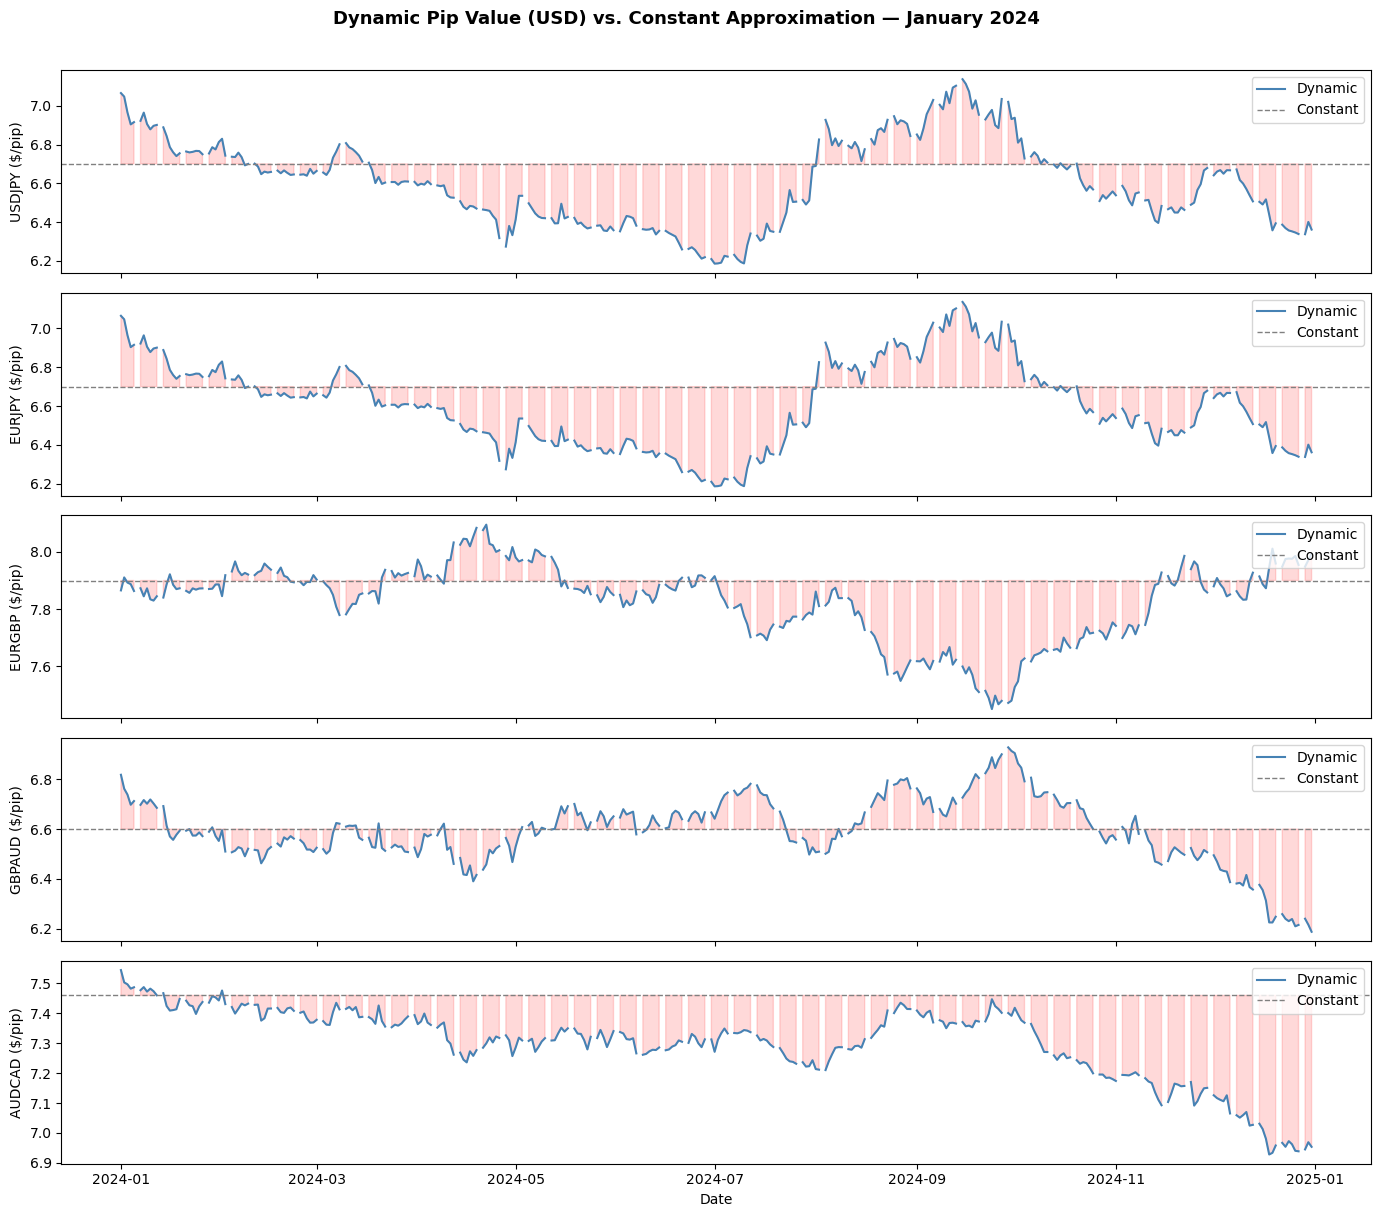

=== Error from Using Constant vs. Dynamic Pip Value ===
USDJPY: constant=$6.70  mean=nan  error: nan% (max nan%)
EURJPY: constant=$6.70  mean=nan  error: nan% (max nan%)
EURGBP: constant=$7.90  mean=nan  error: nan% (max nan%)
GBPAUD: constant=$6.60  mean=nan  error: nan% (max nan%)
AUDCAD: constant=$7.46  mean=nan  error: nan% (max nan%)


In [10]:
# ============================================================
# Constant vs. Dynamic Pip Value Comparison
# ============================================================
import matplotlib.pyplot as plt

# For each non-USD pair, plot the daily dynamic pip value
dynamic_pairs = ['USDJPY','EURJPY','EURGBP','GBPAUD','AUDCAD']
constant_approx = {'USDJPY': 6.70, 'EURJPY': 6.70, 'EURGBP': 7.90, 'GBPAUD': 6.60, 'AUDCAD': 7.46}

fig, axes = plt.subplots(len(dynamic_pairs), 1, figsize=(14, 12), sharex=True)
fig.suptitle('Dynamic Pip Value (USD) vs. Constant Approximation — January 2024',
             fontsize=13, fontweight='bold', y=1.01)

for idx, pair in enumerate(dynamic_pairs):
    ax = axes[idx]
    dates = daily_rates[pair].index
    dyn_vals = [get_dynamic_pip_value(pair, d) for d in dates]
    ax.plot(dates, dyn_vals, label='Dynamic', color='steelblue', lw=1.5)
    ax.axhline(constant_approx[pair], color='gray', ls='--', lw=1, label='Constant')
    ax.fill_between(dates, dyn_vals, constant_approx[pair], alpha=0.15, color='red')
    ax.set_ylabel(f'{pair} ($/pip)')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# Error summary
print('=== Error from Using Constant vs. Dynamic Pip Value ===')
for pair in dynamic_pairs:
    dates = daily_rates[pair].index
    dyn_vals = np.array([get_dynamic_pip_value(pair, d) for d in dates])
    const = constant_approx[pair]
    err_pct = np.abs(dyn_vals - const) / dyn_vals * 100
    print(f'{pair}: constant=${const:.2f}  mean={dyn_vals.mean():.2f}  '
          f'error: {err_pct.mean():.1f}% (max {err_pct.max():.1f}%)')

## Section 3: Simulate Client Base

**500 clients** across 3 tiers, distributed across APAC regions:

| Tier | Count | Win Rate | Trades/Month | Lot Size |
|------|:-----:|:--------:|:------------:|:--------:|
| Tier 1 VIP | 50 | 42-50% | 40-80 | 0.5-1.0 |
| Tier 2 Regular | 200 | 38-45% | 10-35 | 0.05-0.25 |
| Tier 3 Beginner | 250 | 32-40% | 3-12 | 0.01 |

In [ ]:
# ============================================================
# Section 3: Simulate Client Base
# ============================================================
np.random.seed(42)
n_clients = 500
tier1_n, tier2_n, tier3_n = 50, 200, 250
client_ids = ['CL{:04d}'.format(i) for i in range(1, n_clients+1)]
tiers = (['Tier 1 VIP']*tier1_n + ['Tier 2 Regular']*tier2_n + ['Tier 3 Beginner']*tier3_n)
np.random.shuffle(tiers)
regions = ['Hong Kong', 'Singapore', 'Australia', 'Japan', 'China', 'Taiwan', 'Thailand', 'Malaysia']
region_weights = [0.25, 0.20, 0.15, 0.12, 0.10, 0.08, 0.05, 0.05]
start_date = pd.Timestamp('2022-01-01')
end_date   = pd.Timestamp('2024-01-31')
days_range = (end_date - start_date).days

clients = pd.DataFrame({
    'client_id':   client_ids,
    'tier':        tiers,
    'region':      np.random.choice(regions, size=n_clients, p=region_weights),
    'open_date':   start_date + pd.to_timedelta(np.random.randint(0, days_range, n_clients), unit='D'),
    'is_active':   np.random.choice([True, False], size=n_clients, p=[0.82, 0.18]),
})

def assign_lot_size(tier):
    if   tier == 'Tier 1 VIP':     return round(np.random.uniform(0.5, 1.0), 2)
    elif tier == 'Tier 2 Regular': return round(np.random.uniform(0.05, 0.25), 2)
    else:                          return 0.01

def assign_win_rate(tier):
    if   tier == 'Tier 1 VIP':     return round(np.random.uniform(0.42, 0.50), 2)
    elif tier == 'Tier 2 Regular': return round(np.random.uniform(0.38, 0.45), 2)
    else:                          return round(np.random.uniform(0.32, 0.40), 2)

clients['avg_lot_size'] = clients['tier'].apply(assign_lot_size)
clients['win_rate']     = clients['tier'].apply(assign_win_rate)
clients['trades_per_month'] = clients['tier'].apply(
    lambda t: np.random.randint(40, 80)  if t=='Tier 1 VIP' else
              np.random.randint(10, 35)  if t=='Tier 2 Regular' else
              np.random.randint(3, 12))

print('=== Client Base Summary ===')
print('Total clients     :', len(clients))
print('Active clients    : {} ({:.0f}%)'.format(
    clients['is_active'].sum(), clients['is_active'].mean()*100))
print()
print(clients.groupby('tier').agg(
    n_clients=('client_id','count'),
    avg_lot=('avg_lot_size','mean'),
    avg_win_rate=('win_rate','mean'),
    avg_trades_month=('trades_per_month','mean')
).round(2))


In [ ]:
# Visualize client distribution
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Tier distribution
tier_counts = clients['tier'].value_counts().sort_index()
axes[0].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
           colors=[TIER_COLORS[t] for t in tier_counts.index])
axes[0].set_title('Client Distribution by Tier')
# Region distribution
sns.countplot(data=clients, y='region', order=clients['region'].value_counts().index,
             palette='viridis', ax=axes[1])
axes[1].set_title('Client Distribution by Region')
plt.tight_layout()
plt.show()

## Section 3b: Client Account Balance, Leverage & Margin

### Key Formulas
- **Notional Value** = `lot_size x 100,000 x entry_price`
- **Margin Required** = `Notional Value / Leverage`
- **Margin Used %** = `Margin Required / Account Balance x 100`

### Parameter Rationale

| Tier | Account Balance | Max Leverage | Rationale |
|------|:-:|:-:|------|
| Tier 1 VIP | $45,000-$60,000 | 500:1 | Professional traders, larger capital |
| Tier 2 Regular | $8,000-$15,000 | 200:1 | Active retail, moderate capital |
| Tier 3 Beginner | $1,500-$3,000 | 50:1 | New traders, smaller accounts, lower leverage for risk mgmt |

In [ ]:
# ============================================================
# Section 3b: Assign Account Balance & Leverage by Tier
# ============================================================
np.random.seed(42)

TIER_BALANCE = {
    'Tier 1 VIP':     (45000, 60000),
    'Tier 2 Regular': (8000,  15000),
    'Tier 3 Beginner':(1500,  3000),
}
TIER_MAX_LEV = {
    'Tier 1 VIP':     500,
    'Tier 2 Regular': 200,
    'Tier 3 Beginner': 50,
}

def assign_balance(tier):
    lo, hi = TIER_BALANCE[tier]
    base = np.random.uniform(lo, hi)
    noise = np.random.normal(0, (hi-lo)*0.05)
    return round(max(lo, min(hi, base+noise)), 2)

clients['account_balance_usd'] = clients['tier'].apply(assign_balance)
clients['max_leverage'] = clients['tier'].map(TIER_MAX_LEV)

# Typical lot size range per tier (for margin calculation reference)
TIER_LOT_RANGE = {
    'Tier 1 VIP':     (1.0,  5.0),
    'Tier 2 Regular': (0.1,  1.0),
    'Tier 3 Beginner':(0.01, 0.1),
}
def assign_typical_lots(tier):
    lo, hi = TIER_LOT_RANGE[tier]
    return round(np.random.uniform(lo, hi), 2)
clients['typical_lot_size'] = clients['tier'].apply(assign_typical_lots)

display(clients[['client_id','tier','region','account_balance_usd','max_leverage','typical_lot_size']].head(10))
print()
print('=== Account Balance Summary by Tier ===')
print(clients.groupby('tier').agg(
    n_clients=('client_id','count'),
    avg_balance=('account_balance_usd','mean'),
    min_balance=('account_balance_usd','min'),
    max_balance=('account_balance_usd','max'),
    avg_max_lev=('max_leverage','mean'),
    avg_typical_lots=('typical_lot_size','mean')
).round(2))


## Section 4: Generate Simulated Transactions

Each client generates a Poisson-distributed number of trades in January 2024. Each trade picks a random pair, direction, lot size, and simulates P&L based on the client's win rate.

**Broker revenue** (market maker model):
```
spread_revenue = spread_pips x 2 x pip_value x lot_size   (round-turn)
broker_profit = -client_pnl + spread_revenue
```

In [ ]:
# ============================================================
# Section 4: Generate Simulated Transactions
# ============================================================
np.random.seed(42)
ALL_PAIRS = list(fx_data.keys())
transactions = []

for _, client in clients.iterrows():
    n_trades = np.random.poisson(client['trades_per_month'])
    for _ in range(n_trades):
        pair    = np.random.choice(ALL_PAIRS)
        lot     = client['avg_lot_size'] * np.random.uniform(0.5, 1.5)
        lot     = round(lot, 2)
        direction = np.random.choice(['long', 'short'])
        # Random entry date in Jan 2024
        entry_dt = pd.Timestamp('2024-01-01') + pd.Timedelta(days=np.random.randint(0, 31),
                                                         hours=np.random.randint(0, 24))
        # Simulate pips gained from a normal distribution centered on small loss
        avg_pips = 3 if client['tier']=='Tier 1 VIP' else -1
        pips     = np.random.normal(avg_pips, 12)
        # Get entry/exit price from FX data
        df = fx_data[pair]
        entry_price = df['CloseBid'].loc[entry_dt:].iloc[0]
        exit_price  = entry_price + (pips * PIP_SIZE[pair] if direction=='long' else -pips * PIP_SIZE[pair])
        exit_price  = max(exit_price, 0.0001)
        # Use DYNAMIC pip value
        pip_val = get_dynamic_pip_value(pair, entry_dt)
        # Spread at entry
        spread_pips = df['SpreadPips'].loc[entry_dt:].iloc[0]
        # P&L
        client_pnl = pips * pip_val * lot
        spread_rev = spread_pips * 2 * pip_val * lot  # round-turn
        broker_profit = -client_pnl + spread_rev
        transactions.append({
            'client_id':      client['client_id'],
            'tier':          client['tier'],
            'region':        client['region'],
            'pair':          pair,
            'direction':     direction,
            'entry_dt':      entry_dt,
            'exit_dt':       entry_dt + pd.Timedelta(hours=np.random.randint(1, 48)),
            'lot_size':      lot,
            'entry_price':   entry_price,
            'exit_price':    exit_price,
            'pips_gained':   round(pips, 2),
            'pip_value_usd': pip_val,
            'spread_pips':   spread_pips,
            'client_pnl_usd':round(client_pnl, 2),
            'spread_rev_usd':round(spread_rev, 2),
            'broker_profit_usd': round(broker_profit, 2),
        })

tx = pd.DataFrame(transactions)
print(f'Total transactions generated: {len(tx):,}')
print(f'Date range: {tx["entry_dt"].min()} → {tx["entry_dt"].max()}')
display(tx.head(8))


In [ ]:
# ============================================================
# Section 4b: Transaction Data Summary
# ============================================================
print('=== P&L Distribution by Tier ===')
print(tx.groupby('tier')['client_pnl_usd'].agg(
    n='count', mean='mean', median='median', std='std'
).round(2))
print()
print('=== Broker Revenue (Spread) by Tier ===')
print(tx.groupby('tier')['spread_rev_usd'].agg(
    n='count', total='sum', avg='mean'
).round(2))
print()
print(f'Total broker revenue (all clients): ${tx["spread_rev_usd"].sum():,.0f}')
print(f'Total client P&L (net): ${tx["client_pnl_usd"].sum():,.0f}')
print(f'Net broker profit: ${tx["broker_profit_usd"].sum():,.0f}')


### Margin Calculation Per Transaction
Now that transactions exist, we calculate margin metrics for each trade and flag high-risk positions.

In [ ]:
# ============================================================
# Section 3b (cont): Calculate Margin Required per Transaction
# ============================================================
# Merge account info into transactions
tx = tx.merge(
    clients[['client_id','account_balance_usd','max_leverage','typical_lot_size']],
    on='client_id', how='left'
)

# Notional value (USD) ≈ lot_size × 100,000 × entry_price
tx['notional_usd'] = tx['lot_size'] * 100000 * tx['entry_price']

# Margin required (USD) = notional_usd / max_leverage
tx['margin_required_usd'] = tx['notional_usd'] / tx['max_leverage']

# Margin used % = margin_required / account_balance
tx['margin_used_pct'] = tx['margin_required_usd'] / tx['account_balance_usd'] * 100

# Flag high-risk trades
tx['high_risk'] = tx['margin_used_pct'] > 80

display(tx[['client_id','pair','lot_size','notional_usd',
              'margin_required_usd','account_balance_usd','margin_used_pct',
              'high_risk']].head(10))
print()
print('=== Margin Used % Distribution ===')
print(tx['margin_used_pct'].describe().round(2))
print()
print('=== High-Risk Trades (margin > 80%) by Tier ===')
print(tx[tx['high_risk']].groupby('tier').size())


### Margin Call Simulation
Flag trades where `margin_used_pct > 100%` — the broker would force-close these positions.

In [ ]:
# Simulate margin call: if margin_used_pct > 100%, broker closes position
tx['margin_called'] = tx['margin_used_pct'] > 100

print('=== Margin Call Risk Summary ===')
print(f'Trades with >100% margin used: {tx["margin_called"].sum()}')
print()
at_risk = tx[tx['high_risk']].groupby('client_id')['margin_used_pct'].max()
print(f'Clients with at least 1 high-risk trade: {len(at_risk)} / {clients["client_id"].nunique()}')
print()
print('Top 10 clients by max margin used %:')
print(at_risk.sort_values(ascending=False).head(10).round(1))

## Export Data to CSV
Save the generated data for the analysis notebook.

In [ ]:
# ============================================================
# Export to CSV
# ============================================================
OUTPUT_DIR = './'  # same directory; change if needed

clients.to_csv(OUTPUT_DIR + 'clients.csv', index=False)
tx.to_csv(OUTPUT_DIR + 'transactions.csv', index=False)

print('=== Data Exported ===')
print(f'clients.csv      : {len(clients):,} rows x {len(clients.columns)} cols')
print(f'transactions.csv : {len(tx):,} rows x {len(tx.columns)} cols')
print()
print('Column list — clients.csv:')
print(list(clients.columns))
print()
print('Column list — transactions.csv:')
print(list(tx.columns))
print()
print('>>> Now open FX_analysis.ipynb to analyze the data.')